In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler,LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RepeatedStratifiedKFold,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import KFold
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import EarlyStopping
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from keras.utils import plot_model
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
path = "https://raw.githubusercontent.com/OmarEladl/Traffic-jam-analysis/main/Roads_Accidents_data.xlsx"
df = pd.read_excel(path)
df.head()

,Time,Day_of_week,Age_of_The_Driver,Sex_of_driver,Vehicle_driver_relation,Driving_experience2,Area_accident_occured,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Employee,1-2yr,Residential areas,No junction,Asphalt roads,Dry,Daylight,Normal,2,2,Going straight,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Employee,Above 10yr,Office areas,No junction,Asphalt roads,Dry,Daylight,Normal,2,2,Going straight,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Employee,1-2yr,Recreational areas,No junction,Asphalt roads,Dry,Daylight,Normal,2,2,Going straight,Changing lane to the left,Serious Injury
3,01:06:00,Sunday,18-30,Male,Employee,5-10yr,Office areas,Y Shape,Earth roads,Dry,Darkness - lights lit,Normal,2,2,Going straight,Changing lane to the right,Slight Injury
4,01:06:00,Sunday,18-30,Male,Employee,2-5yr,Industrial areas,Y Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,2,2,Going straight,Overtaking,Slight Injury


In [4]:
df.shape

(12316, 17)

In [5]:
df.describe(include="all")

,Time,Day_of_week,Age_of_The_Driver,Sex_of_driver,Vehicle_driver_relation,Driving_experience2,Area_accident_occured,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Cause_of_accident,Accident_severity
count,12316,12316,12316,12316,12316,12316,12316,12316,12316,12316,12316,12316,12316.000000,12316.000000,12316,12316,12316
unique,1074,7,5,3,4,8,14,8,6,4,4,9,NaN,NaN,13,20,3
top,15:30:00,Friday,18-30,Male,Employee,5-10yr,Other,Y Shape,Asphalt roads,Dry,Daylight,Normal,NaN,NaN,Going straight,No distancing,Slight Injury
freq,120,2041,4271,11437,9627,3363,3819,4543,11296,9340,8798,10063,NaN,NaN,8158,2263,10415
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.040679,1.548149,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.688790,1.007179,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,1.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,1.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN,NaN


In [6]:
df.columns

Index(['Time', 'Day_of_week', 'Age_of_The_Driver', 'Sex_of_driver',
       'Vehicle_driver_relation', 'Driving_experience2',
       'Area_accident_occured', 'Types_of_Junction', 'Road_surface_type',
       'Road_surface_conditions', 'Light_conditions', 'Weather_conditions',
       'Number_of_vehicles_involved', 'Number_of_casualties',
       'Vehicle_movement', 'Cause_of_accident', 'Accident_severity'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_of_The_Driver            12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Vehicle_driver_relation      12316 non-null  object
 5   Driving_experience2          12316 non-null  object
 6   Area_accident_occured        12316 non-null  object
 7   Types_of_Junction            12316 non-null  object
 8   Road_surface_type            12316 non-null  object
 9   Road_surface_conditions      12316 non-null  object
 10  Light_conditions             12316 non-null  object
 11  Weather_conditions           12316 non-null  object
 12  Number_of_vehicles_involved  12316 non-null  int64 
 13  Number_of_casualties         12

In [8]:
df['Time'] = pd.to_datetime(df['Time'].astype(str))

In [9]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
12311,False
12312,False
12313,False
12314,False


In [10]:
df.duplicated().sum()

np.int64(15)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.groupby('Accident_severity').size()

,0
Accident_severity,
Fatal injury,158
Serious Injury,1742
Slight Injury,10401


In [13]:
df.isnull().sum()

,0
Time,0
Day_of_week,0
Age_of_The_Driver,0
Sex_of_driver,0
Vehicle_driver_relation,0
Driving_experience2,0
Area_accident_occured,0
Types_of_Junction,0
Road_surface_type,0
Road_surface_conditions,0


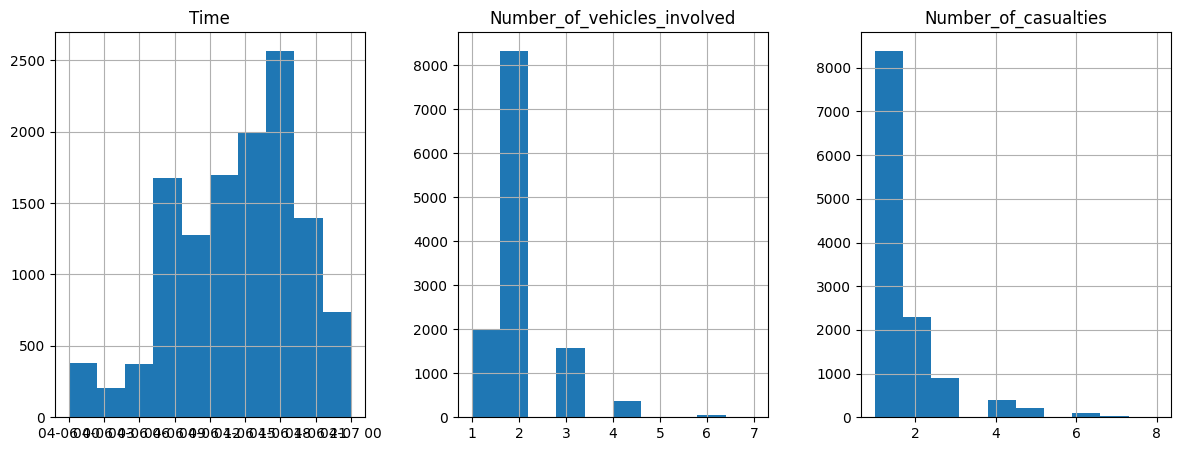

In [14]:
df.hist(layout=(1,6), figsize=(30,5))
plt.show()

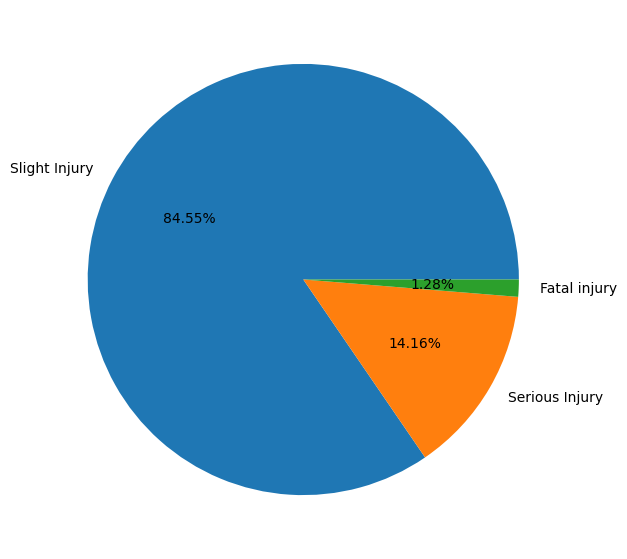

In [15]:
plt.figure(figsize=(10,7))
plt.pie(x=df['Accident_severity'].value_counts().values,
        labels=df['Accident_severity'].value_counts().index,
        autopct='%2.2f%%')
plt.show()

In [16]:
x = df.drop('Accident_severity', axis=1)
y = df['Accident_severity']

In [17]:
df_encoded = x.copy()
# Extract hour from 'Time' column for numerical representation
df_encoded['Time_hour'] = df_encoded['Time'].dt.hour
df_encoded = df_encoded.drop('Time', axis=1)

# Apply LabelEncoder to all remaining object type columns
for column in df_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_encoded[column] = le.fit_transform(df_encoded[column])

<Axes: >

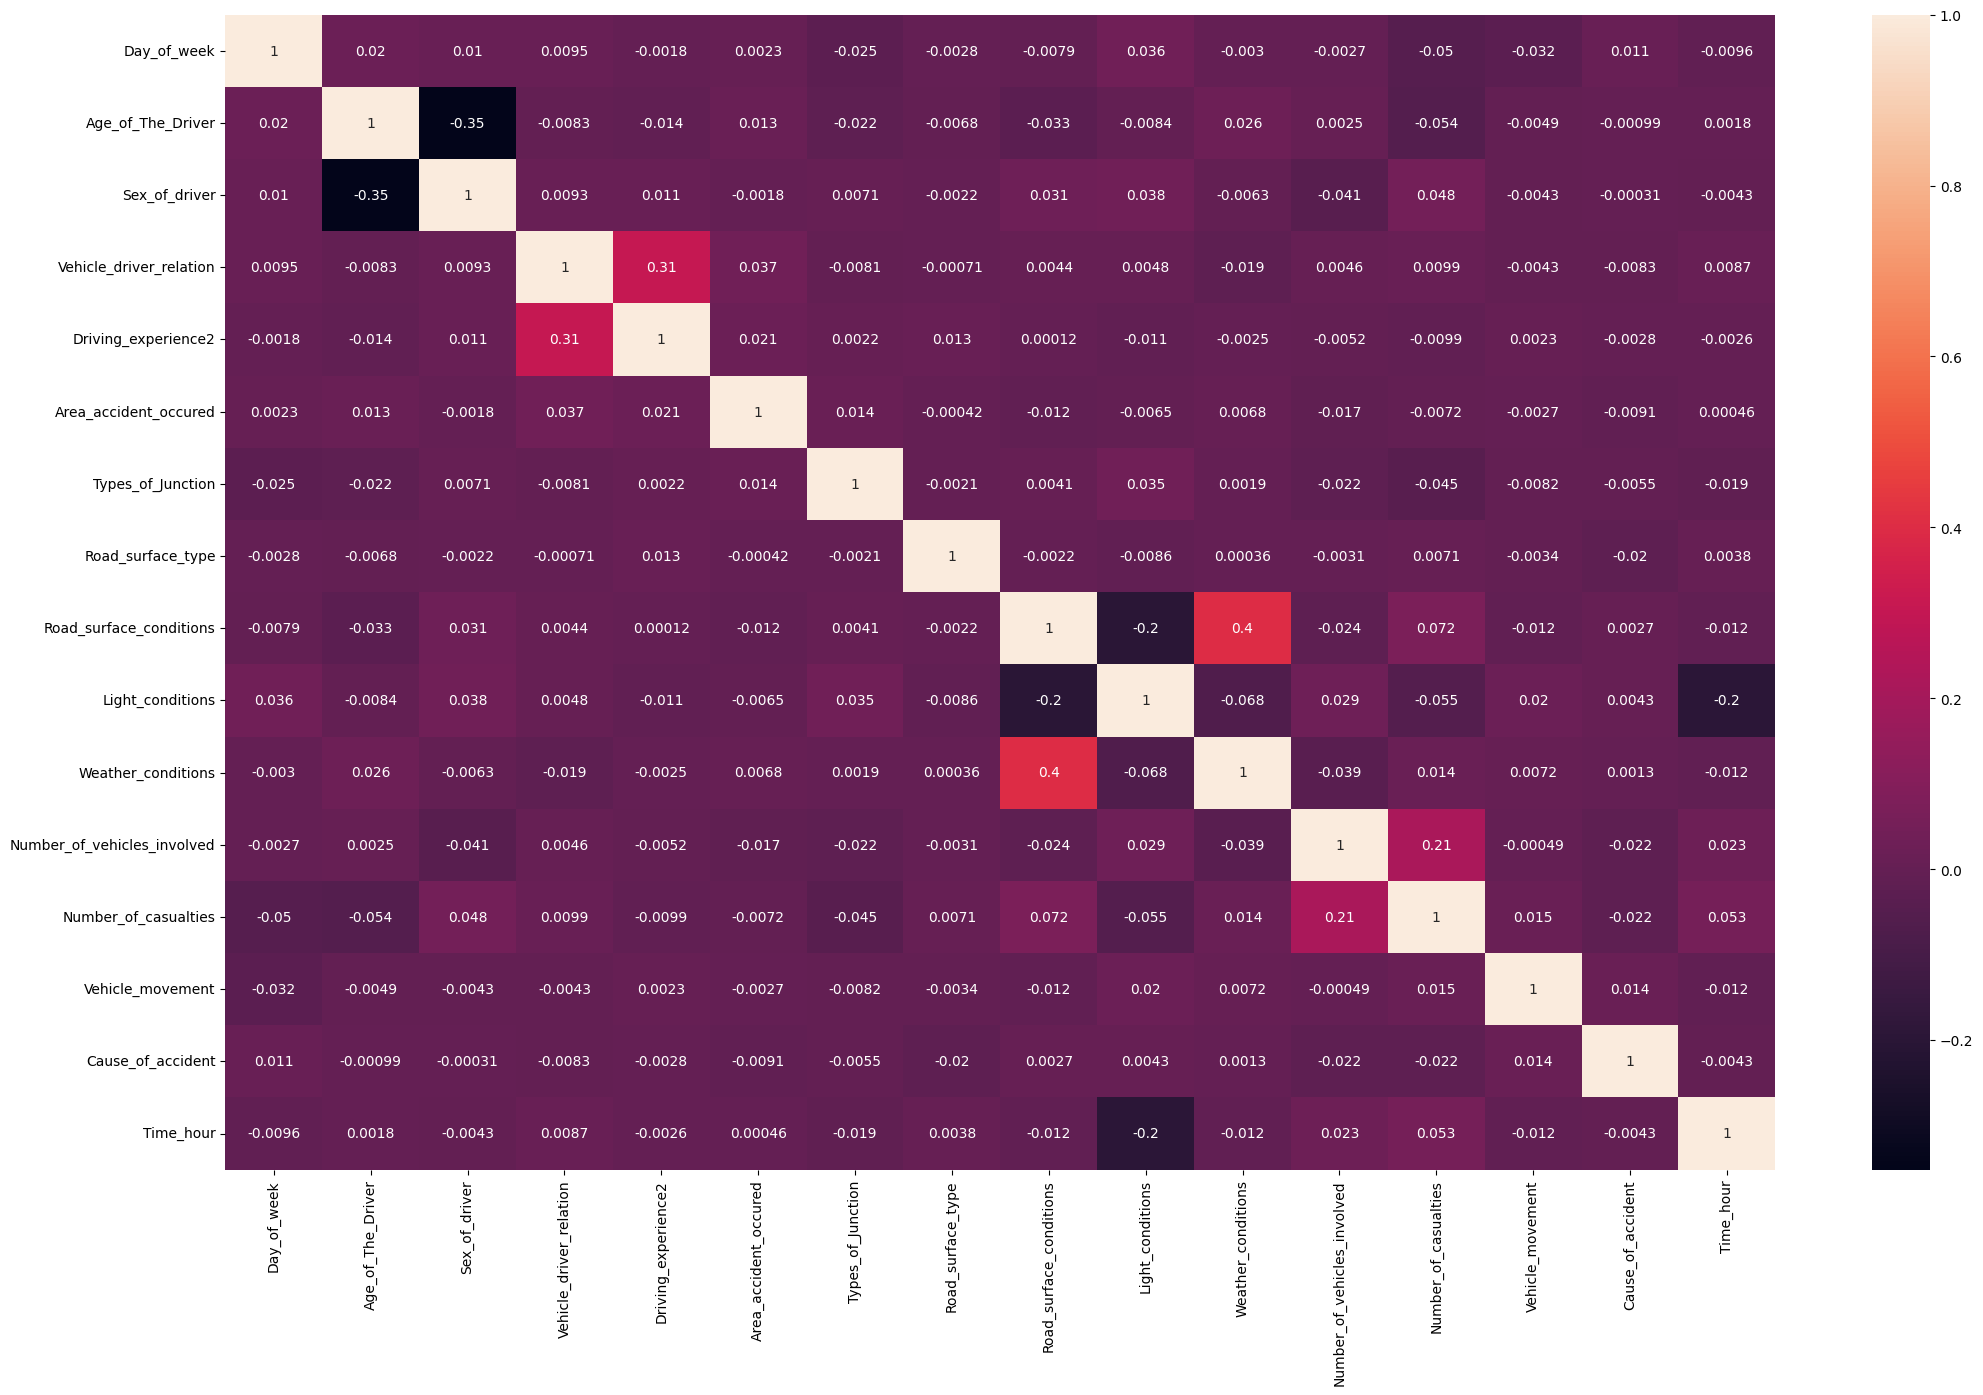

In [18]:
import seaborn as sns
plt.figure(figsize=[25,15])
sns.heatmap(df_encoded.corr(),annot=True)

In [19]:
x_features = df_encoded # Use the already preprocessed numerical features

# Encode the target variable y into numerical format
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(df['Accident_severity'])

xtrain, xtest, ytrain, ytest = train_test_split(x_features, y_encoded, test_size=0.25, random_state=36)

In [20]:
print(xtrain.shape, xtest.shape, ytrain.shape, ytest.shape)

(9225, 16) (3076, 16) (9225,) (3076,)


In [21]:
df_encoded

,Day_of_week,Age_of_The_Driver,Sex_of_driver,Vehicle_driver_relation,Driving_experience2,Area_accident_occured,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Cause_of_accident,Time_hour
0,1,0,1,0,0,9,1,0,0,3,2,2,2,2,9,17
1,1,1,1,0,3,6,1,0,0,3,2,2,2,2,16,17
2,1,0,1,0,0,1,1,0,0,3,2,2,2,2,0,17
3,3,0,1,0,2,6,7,2,0,0,2,2,2,2,1,1
4,3,0,1,0,1,4,7,0,0,0,2,2,2,2,16,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12311,6,1,1,0,1,5,1,0,0,3,2,2,1,2,10,16
12312,3,4,1,0,2,5,1,0,0,3,2,2,1,4,10,18
12313,3,2,1,0,2,5,1,0,0,3,2,1,1,4,1,13
12314,3,0,0,0,3,6,1,0,0,0,2,2,1,4,5,13


In [22]:
y_encoded

array([2, 2, 1, ..., 1, 2, 2])

In [23]:
models={"LogisticRegression":LogisticRegression(),
        "DecisionTreeClassifier":DecisionTreeClassifier(),
        "SVM":SVC(),
        "KNeighborsClassifier":KNeighborsClassifier(),
        "GNB":GaussianNB(),
       "RandomForestClassifier":RandomForestClassifier(),
        "AdaBoostClassifier":AdaBoostClassifier(),
        "GradientBoostingClassifier":GradientBoostingClassifier(),
        }

In [24]:
# models,x,y,scaleFlag=0,1,2
def modelAccuracy(models,x,y,scaleFlag):
    #train/Test
    xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=0)
    acc_result={}
    for name,model in models.items():
        #pipeline
        #1.Transformer -> 2.Model
        if(scaleFlag==1):
            model_pipeline=Pipeline([('MinMaxScler',MinMaxScaler()),('model',model)])
        elif(scaleFlag==2):
             model_pipeline=Pipeline([('StandardScaler',StandardScaler()),('model',model)])
        else:
            model_pipeline=Pipeline([('model',model)])
        #training/testing on model pipeline
        model_fit=model_pipeline.fit(xtrain,ytrain)
        ypred=model_fit.predict(xtest)
        acc=accuracy_score(ytest,ypred)
        print("The Accuracy for ",name," is :",acc)
        acc_result[name]=acc
    return acc_result

In [25]:
def bestModel(result):
    high=0
    for name,acc in result.items():
        if acc>high:
            high=acc
            model_name=name
    print("Best Model is ",model_name," with accuaracy =>",high)

In [26]:
def bestParams(model,param,xtrain,ytrain):
    #cv
    cv=RepeatedStratifiedKFold(n_splits=5,n_repeats=3)
    grid_cv=GridSearchCV(estimator=model,param_grid=param,cv=cv,scoring="f1_weighted")
    res=grid_cv.fit(xtrain,ytrain)
    print("Best Parameters are ",res.best_params_)
    print("Best Accuracy is ",res.best_score_)

In [27]:
bestParams

<function __main__.bestParams(model, param, xtrain, ytrain)>

In [28]:
acc=modelAccuracy(models,df_encoded,y_encoded,1)

The Accuracy for  LogisticRegression  is : 0.8350264120276311
The Accuracy for  DecisionTreeClassifier  is : 0.7639171068671272
The Accuracy for  SVM  is : 0.8350264120276311
The Accuracy for  KNeighborsClassifier  is : 0.8199918732222674
The Accuracy for  GNB  is : 0.8220235676554246
The Accuracy for  RandomForestClassifier  is : 0.8476229175132061
The Accuracy for  AdaBoostClassifier  is : 0.8350264120276311
The Accuracy for  GradientBoostingClassifier  is : 0.8403088175538399


In [29]:
bestModel(acc)

Best Model is  RandomForestClassifier  with accuaracy => 0.8476229175132061


In [30]:
model=RandomForestClassifier()
params={"n_estimators" : [150,200],
        "criterion" : ["gini","entropy"]
        }
bestParams(model,params,xtrain,ytrain)

Best Parameters are  {'criterion': 'entropy', 'n_estimators': 200}
Best Accuracy is  0.7997842065850365


In [31]:
#retrain the model with best parameters
model=RandomForestClassifier()
model.fit(xtrain,ytrain)
ypred=model.predict(xtest)

0.8504551365409623
              precision    recall  f1-score   support

           0       1.00      0.05      0.09        42
           1       0.82      0.10      0.18       456
           2       0.85      1.00      0.92      2578

    accuracy                           0.85      3076
   macro avg       0.89      0.38      0.40      3076
weighted avg       0.85      0.85      0.80      3076



<Axes: >

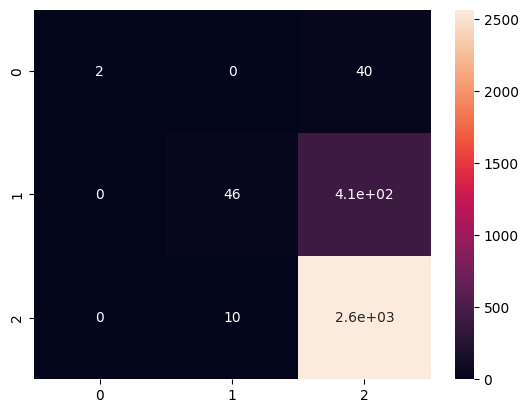

In [32]:
#Final Evaluation
print(accuracy_score(ytest,ypred))
print(classification_report(ytest,ypred))
cm=confusion_matrix(ytest,ypred)
sns.heatmap(cm,annot=True)

# DP

In [33]:
z = pd.get_dummies(x, drop_first=True)

In [34]:
df_encodedz = z.copy()
# Extract hour from 'Time' column for numerical representation
df_encodedz['Time_hour'] = df_encodedz['Time'].dt.hour
df_encodedz = df_encodedz.drop('Time', axis=1)

# Apply LabelEncoder to all remaining object type columns
for column in df_encodedz.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_encodedz[column] = le.fit_transform(df_encodedz[column])

# Convert all boolean columns to integer type (0 or 1) for TensorFlow compatibility
for col in df_encodedz.select_dtypes(include='bool').columns:
    df_encodedz[col] = df_encodedz[col].astype(int)

In [35]:
scaler = StandardScaler()
df_encodedz = scaler.fit_transform(df_encodedz)

In [36]:
xtrain,xtest,ytrain,ytest=train_test_split(df_encodedz,y_encoded,test_size=0.2,random_state=0)

In [37]:
oversample = SMOTE()
xtrain, ytrain = oversample.fit_resample(xtrain, ytrain)

## Building and Evaluating `modelDP1`

Training modelDP1...
Epoch 1/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4741 - loss: 1.0196 - val_accuracy: 0.0000e+00 - val_loss: 1.1381
Epoch 2/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6400 - loss: 0.7742 - val_accuracy: 0.0000e+00 - val_loss: 0.9514
Epoch 3/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6942 - loss: 0.6428 - val_accuracy: 0.0000e+00 - val_loss: 0.8807
Epoch 4/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7068 - loss: 0.6049 - val_accuracy: 0.0000e+00 - val_loss: 0.8814
Epoch 5/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7105 - loss: 0.5775 - val_accuracy: 0.0000e+00 - val_loss: 0.9011
Epoch 6/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7126 - loss: 0.5720 - val_accuracy: 0.0000e+00 - val_loss: 0.8746
Epoch 7/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7156 - loss: 0.5653 - val_accuracy: 0.0000e+00 - val_loss: 0.8973
Epoch 8/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/

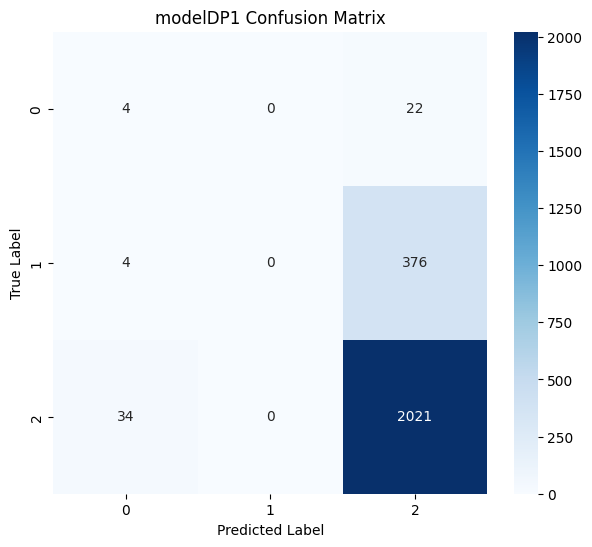

In [92]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

modelDP1 = Sequential([
    Dense(units = 16, activation = 'relu', input_shape=(xtrain.shape[1],)),
    Dropout(0.25),
    Dense(units = 8, activation = 'relu'),
    Dropout(0.22),
    Dense(units = 4, activation = 'relu'),
    Dropout(0.2),
    # Corrected: 3 units for 3 classes and softmax activation for multiclass classification
    Dense(units = 3, activation = 'softmax')
])

# Compile modelDP1
modelDP1.compile(optimizer = Adam(learning_rate=0.0026), loss='sparse_categorical_crossentropy', metrics = ['accuracy'])

print("Training modelDP1...")
# Train modelDP1 - could also add callbacks for early stopping or learning rate reduction
history_dp1 = modelDP1.fit(x = xtrain, y = ytrain, batch_size=32, epochs = 100, verbose=1, validation_split=0.1,callbacks=[early_stop])

# Evaluate modelDP1
print("\nEvaluating modelDP1...")
loss_dp1, accuracy_dp1 = modelDP1.evaluate(xtest, ytest, verbose=0)
print(f"modelDP1 Test Accuracy: {accuracy_dp1:.4f}")

# Get predictions
y_pred_probs_dp1 = modelDP1.predict(xtest)
y_pred_dp1 = np.argmax(y_pred_probs_dp1, axis=1)

# Classification Report
print("\nmodelDP1 Classification Report:")
print(classification_report(ytest, y_pred_dp1))

# Confusion Matrix
cm_dp2 = confusion_matrix(ytest, y_pred_dp1)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_dp2, annot=True, fmt='d', cmap='Blues')
plt.title('modelDP1 Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

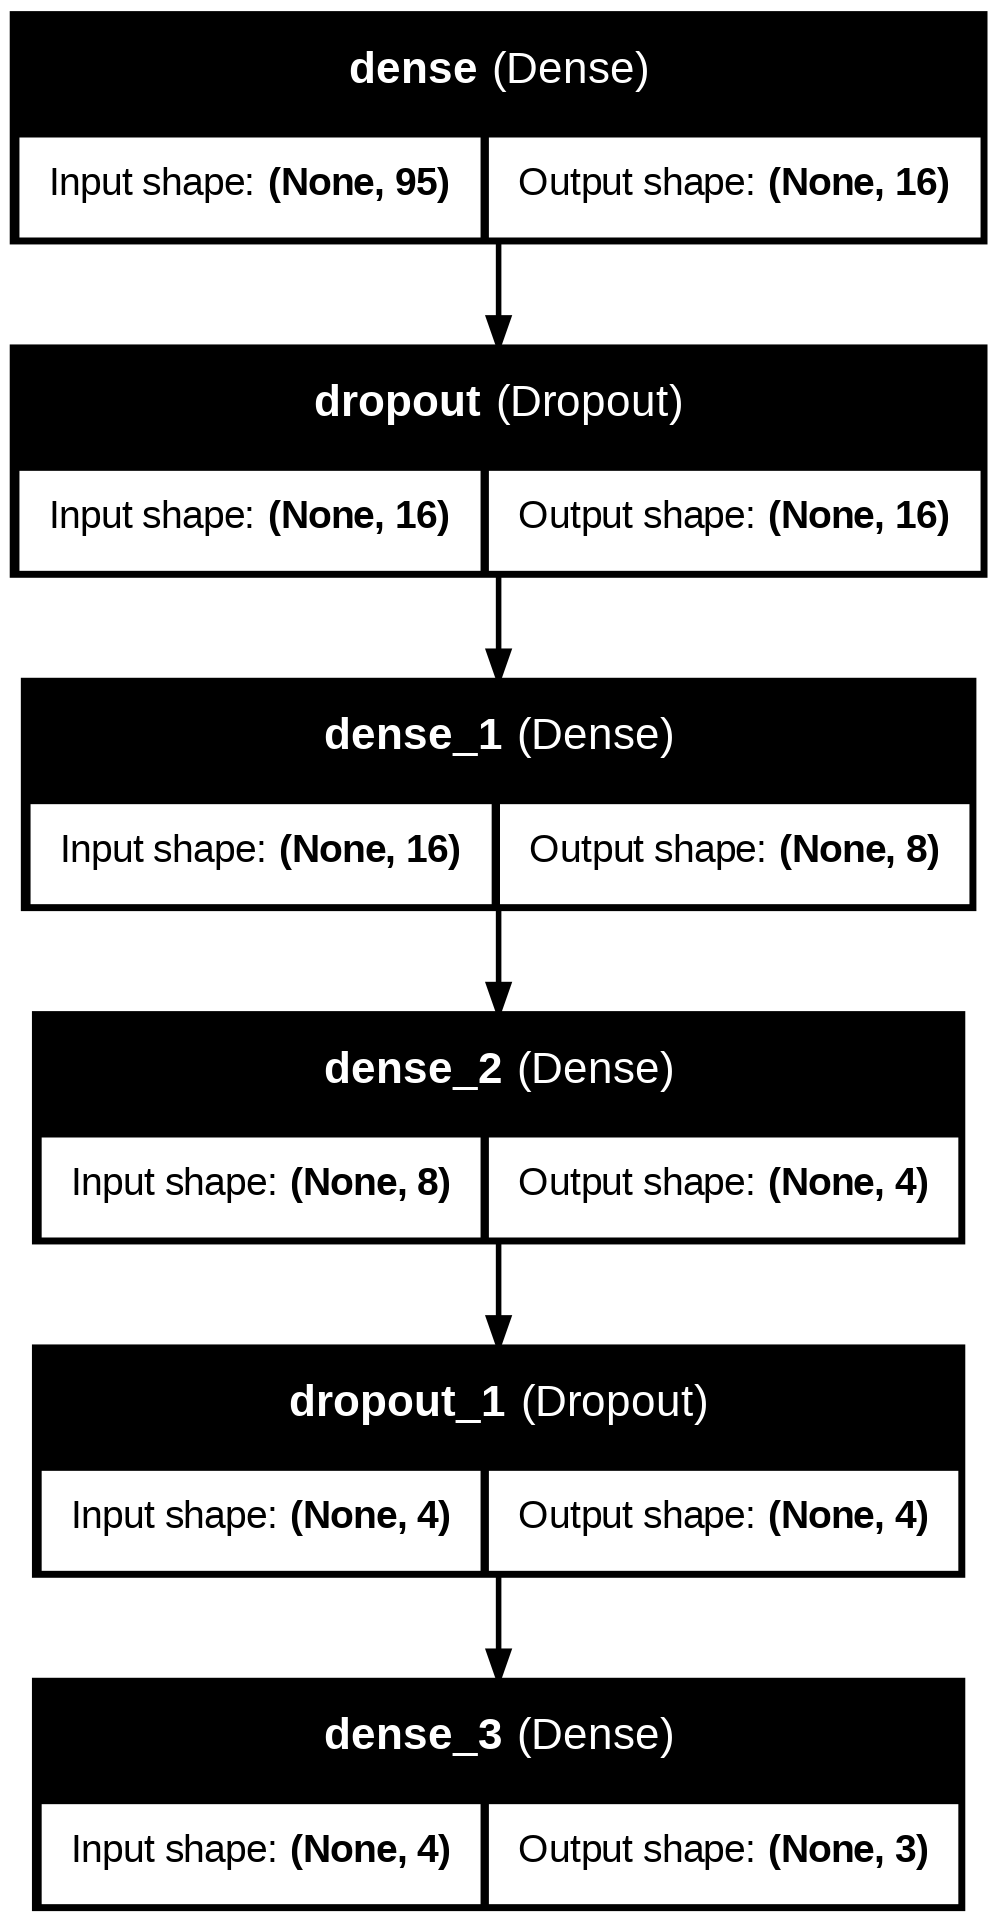

In [39]:
plot_model(modelDP1, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

## Building and Evaluating `modelDP2`





Training modelDP2...
Epoch 1/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6226 - loss: 0.7514 - val_accuracy: 0.0000e+00 - val_loss: 0.9509
Epoch 2/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7062 - loss: 0.5549 - val_accuracy: 0.0000e+00 - val_loss: 0.9654
Epoch 3/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7156 - loss: 0.5173 - val_accuracy: 0.0000e+00 - val_loss: 0.9550
Epoch 4/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7158 - loss: 0.5090 - val_accuracy: 0.1394 - val_loss: 0.7488
Epoch 5/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7193 - loss: 0.4951 - val_accuracy: 0.1737 - val_loss: 0.7805
Epoch 6/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7252 - loss: 0.4910 - val_accuracy: 0.2448 - val_loss: 0.7887
Epoch 7/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7345 - loss: 0.4868 - val_accuracy: 0.5679 - val_loss: 0.7121
Epoch 8/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy:

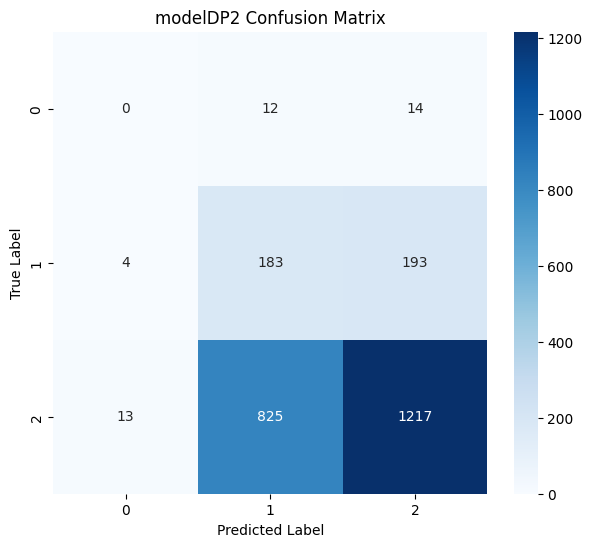

In [99]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

# Define modelDP2 with a slightly deeper or wider architecture for potential improvement
modelDP2 = Sequential([
    Dense(units=64, activation='relu', input_shape=(xtrain.shape[1],)), # Wider first layer
    Dropout(0.2), # Increased dropout
    Dense(units=32, activation='relu'), # Added another layer or increased units
    Dense(units=16, activation='relu'),
    Dropout(0.3),
    Dense(units=4, activation='relu'),
    Dropout(0.2),
    Dense(units=3, activation='softmax') # Output layer for 3 classes
])

# Compile modelDP2
modelDP2.compile(optimizer=Adam(learning_rate=0.0026),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

print("Training modelDP2...")
# Train modelDP2 - could also add callbacks for early stopping or learning rate reduction
history_dp2 = modelDP2.fit(x=xtrain, y=ytrain, batch_size=32, epochs=100, verbose=1, validation_split=0.1,callbacks=[early_stop])

# Evaluate modelDP2
print("\nEvaluating modelDP2...")
loss_dp2, accuracy_dp2 = modelDP2.evaluate(xtest, ytest, verbose=0)
print(f"modelDP2 Test Accuracy: {accuracy_dp2:.4f}")

# Get predictions
y_pred_probs_dp2 = modelDP2.predict(xtest)
y_pred_dp2 = np.argmax(y_pred_probs_dp2, axis=1)

# Classification Report
print("\nmodelDP2 Classification Report:")
print(classification_report(ytest, y_pred_dp2))

# Confusion Matrix
cm_dp2 = confusion_matrix(ytest, y_pred_dp2)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_dp2, annot=True, fmt='d', cmap='Blues')
plt.title('modelDP2 Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

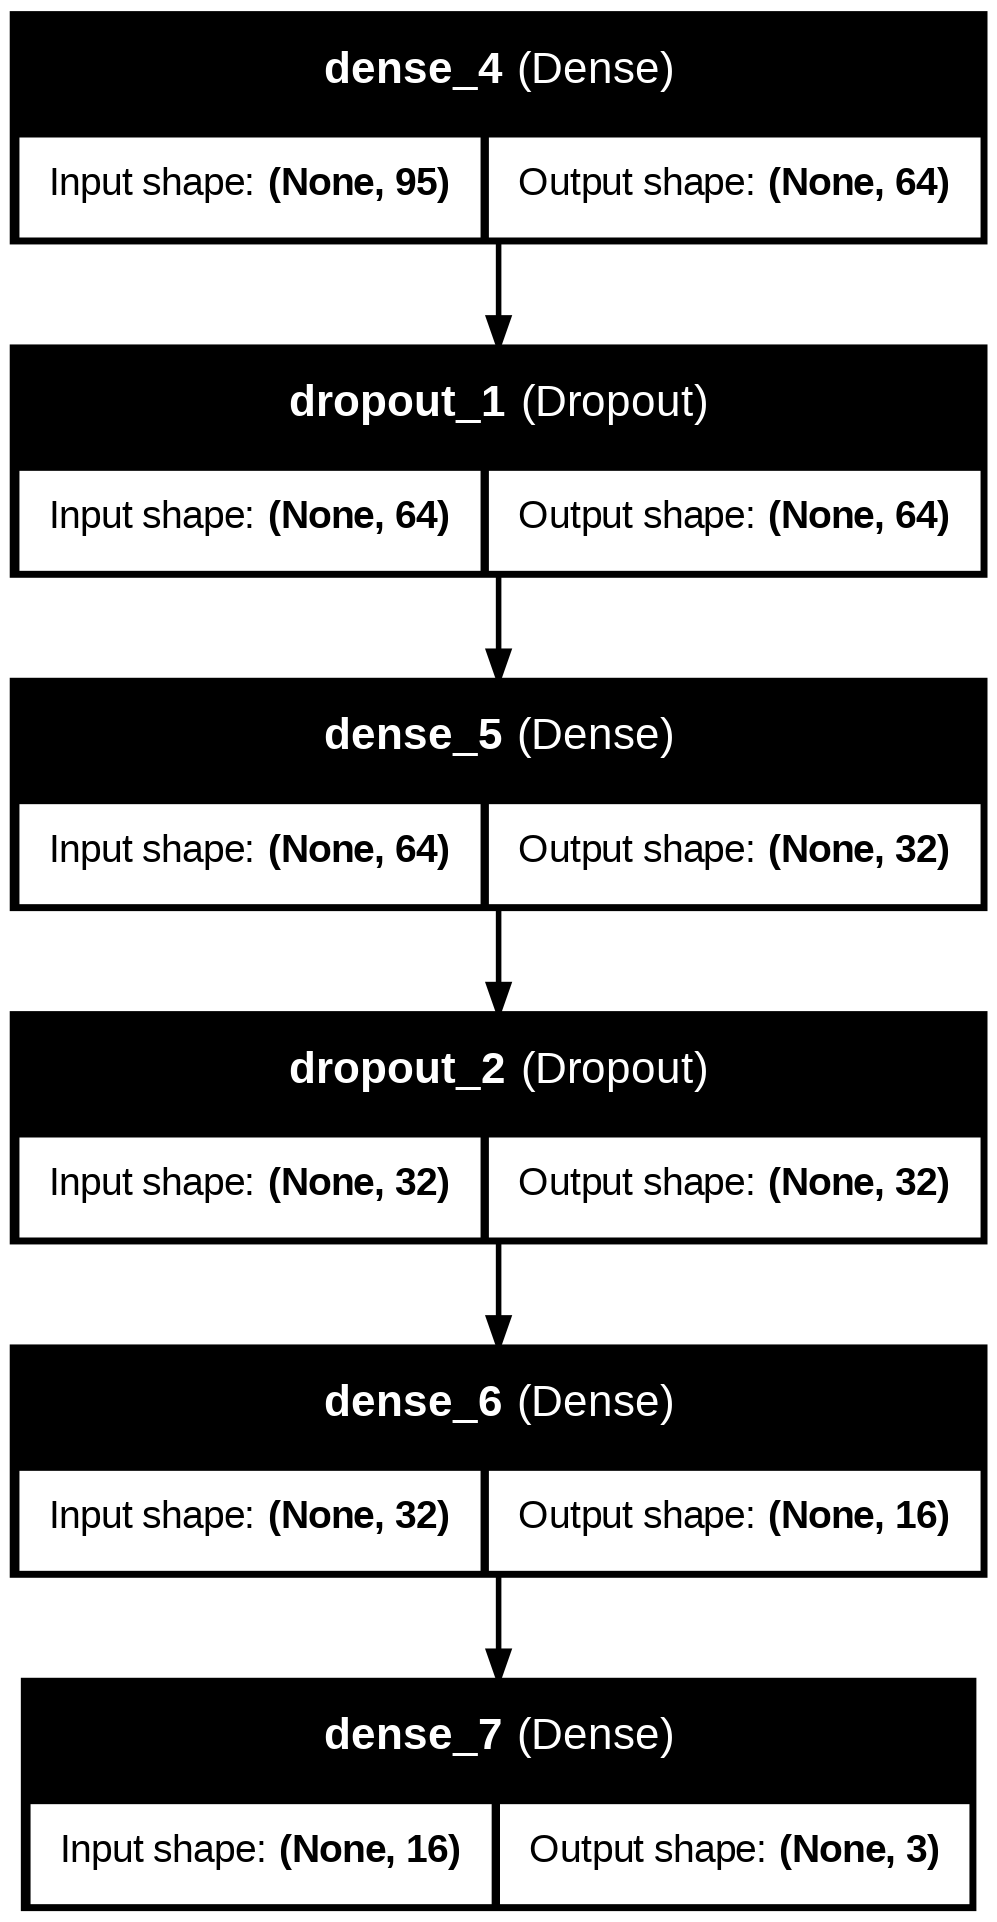

In [41]:
plot_model(modelDP2, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

## Building and Evaluating `modelDP3`

Training modelDP1...
Epoch 1/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5507 - loss: 0.9318 - val_accuracy: 0.0000e+00 - val_loss: 1.0786
Epoch 2/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6694 - loss: 0.6840 - val_accuracy: 0.0000e+00 - val_loss: 0.9099
Epoch 3/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7076 - loss: 0.5745 - val_accuracy: 0.0000e+00 - val_loss: 0.8900
Epoch 4/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7177 - loss: 0.5353 - val_accuracy: 0.0000e+00 - val_loss: 0.8804
Epoch 5/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7218 - loss: 0.5175 - val_accuracy: 0.0000e+00 - val_loss: 0.8684
Epoch 6/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7232 - loss: 0.5123 - val_accuracy: 0.0000e+00 - val_loss: 0.9259
Epoch 7/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7250 - loss: 0.5011 - val_accuracy: 0.0000e+00 - val_loss: 0.8552
Epoch 8/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/

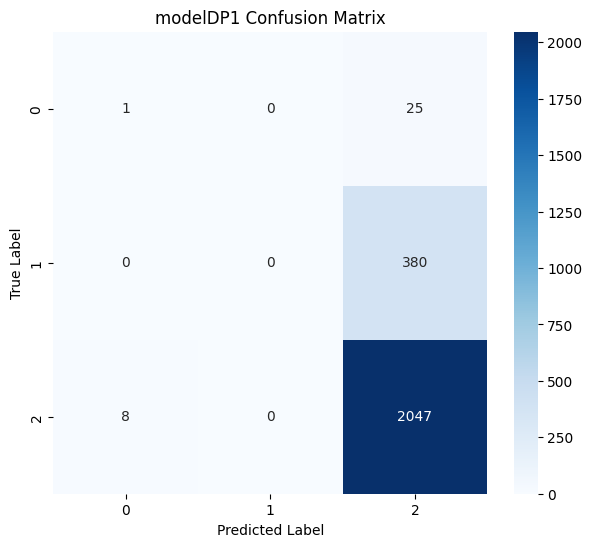

In [100]:
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(ytrain),
    y=ytrain
)

class_weights_dict = dict(enumerate(class_weights))

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

# Define modelDP4 with a deeper and wider architecture
modelDP1 = Sequential([
   Dense(units=32, activation='relu', input_shape=(xtrain.shape[1],)), # Wider first layer
    Dropout(0.24), # Increased dropout
    Dense(units=16, activation='relu'), # Added another layer or increased units
    Dense(units=8, activation='relu'), # Additional layer
    Dropout(0.26),
    Dense(units=4, activation='relu'), # Additional layer
    Dropout(0.24),
    Dense(units=3, activation='softmax') # Output layer for 3 classes
])

# Compile modelDP1
modelDP1.compile(optimizer = Adam(learning_rate=0.0026), loss='sparse_categorical_crossentropy', metrics = ['accuracy'])

print("Training modelDP1...")
# Train modelDP1 - could also add callbacks for early stopping or learning rate reduction
history_dp1 = modelDP1.fit(x = xtrain, y = ytrain, batch_size=32, epochs = 100, verbose=1, validation_split=0.1,callbacks=[early_stop],class_weight=class_weights_dict)

# Evaluate modelDP1
print("\nEvaluating modelDP1...")
loss_dp1, accuracy_dp1 = modelDP1.evaluate(xtest, ytest, verbose=0)
print(f"modelDP1 Test Accuracy: {accuracy_dp1:.4f}")

# Get predictions
y_pred_probs_dp1 = modelDP1.predict(xtest)
y_pred_dp1 = np.argmax(y_pred_probs_dp1, axis=1)

# Classification Report
print("\nmodelDP1 Classification Report:")
print(classification_report(ytest, y_pred_dp1))

# Confusion Matrix
cm_dp2 = confusion_matrix(ytest, y_pred_dp1)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_dp2, annot=True, fmt='d', cmap='Blues')
plt.title('modelDP1 Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Building and Evaluating `modelDP4` (with `ReduceLROnPlateau`)

Training modelDP4...
Epoch 1/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5171 - loss: 0.9486 - val_accuracy: 0.0659 - val_loss: 1.0511 - learning_rate: 6.0000e-04
Epoch 2/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6364 - loss: 0.6923 - val_accuracy: 0.1066 - val_loss: 0.9079 - learning_rate: 6.0000e-04
Epoch 3/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6930 - loss: 0.5583 - val_accuracy: 0.0371 - val_loss: 0.8738 - learning_rate: 6.0000e-04
Epoch 4/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7172 - loss: 0.4887 - val_accuracy: 0.0707 - val_loss: 0.7904 - learning_rate: 6.0000e-04
Epoch 5/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7266 - loss: 0.4624 - val_accuracy: 0.0811 - val_loss: 0.8262 - learning_rate: 6.0000e-04
Epoch 6/100
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7345 - loss: 0.4508 - val_accuracy: 0.0735 - val_loss: 0.8356 - learning_rate: 6.0000e-04
Epoch 7/100
705/705 ━━━━━━━━━━━━━━━━━

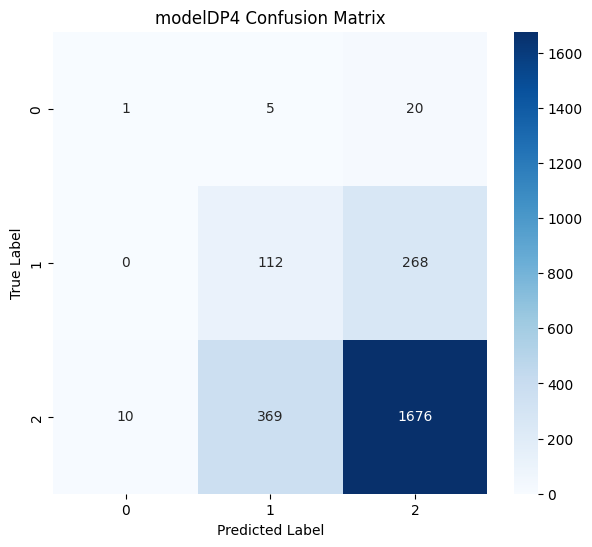

In [85]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=25, # Increased patience for longer training
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2, # Reduce learning rate by 20% when val_loss plateaus
    patience=6, # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=0.001, # Lower bound on the learning rate
    verbose=1
)


# Define modelDP4 with a deeper and wider architecture
modelDP4 = Sequential([
    Dense(units=64, activation='relu', input_shape=(xtrain.shape[1],)), # Wider first layer
    Dropout(0.2), # Increased dropout
    Dense(units=32, activation='relu'), # Added another layer or increased units
    Dense(units=8, activation='relu'), # Additional layer
    Dropout(0.2),
    Dense(units=3, activation='softmax') # Output layer for 3 classes
])

# Compile modelDP4
modelDP4.compile(optimizer=Adam(learning_rate=0.0006),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

print("Training modelDP4...")
# Train modelDP4 with EarlyStopping, ReduceLROnPlateau, and class weights
history_dp4 = modelDP4.fit(x=xtrain, y=ytrain, batch_size=32, epochs=100, verbose=1, validation_split=0.1, callbacks=[early_stop, reduce_lr], class_weight=class_weights_dict)

# Evaluate modelDP4
print("\nEvaluating modelDP4...")
loss_dp4, accuracy_dp4 = modelDP4.evaluate(xtest, ytest, verbose=0)
print(f"modelDP4 Test Accuracy: {accuracy_dp4:.4f}")

# Get predictions
y_pred_probs_dp4 = modelDP4.predict(xtest)
y_pred_dp4 = np.argmax(y_pred_probs_dp4, axis=1)

# Classification Report
print("\nmodelDP4 Classification Report:")
print(classification_report(ytest, y_pred_dp4))

# Confusion Matrix
cm_dp4 = confusion_matrix(ytest, y_pred_dp4)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_dp4, annot=True, fmt='d', cmap='Blues')
plt.title('modelDP4 Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()